C:\Users\chand\AppData\Local\Temp\ipykernel_31964\1940608444.py:184: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\chand\AppData\Local\Temp\ipykernel_31964\1940608444.py:184: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\chand\AppData\Local\Temp\ipykernel_31964\1940608444.py:185: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{DATA_DIR}/song_blobs.png", dpi=150,
C:\Users\chand\AppData\Local\Temp\ipykernel_31964\1940608444.py:185: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{DATA_DIR}/song_blobs.png", dpi=150,
C:\Users\chand\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\chand\AppData\Roaming\Python\Python310\site-packag

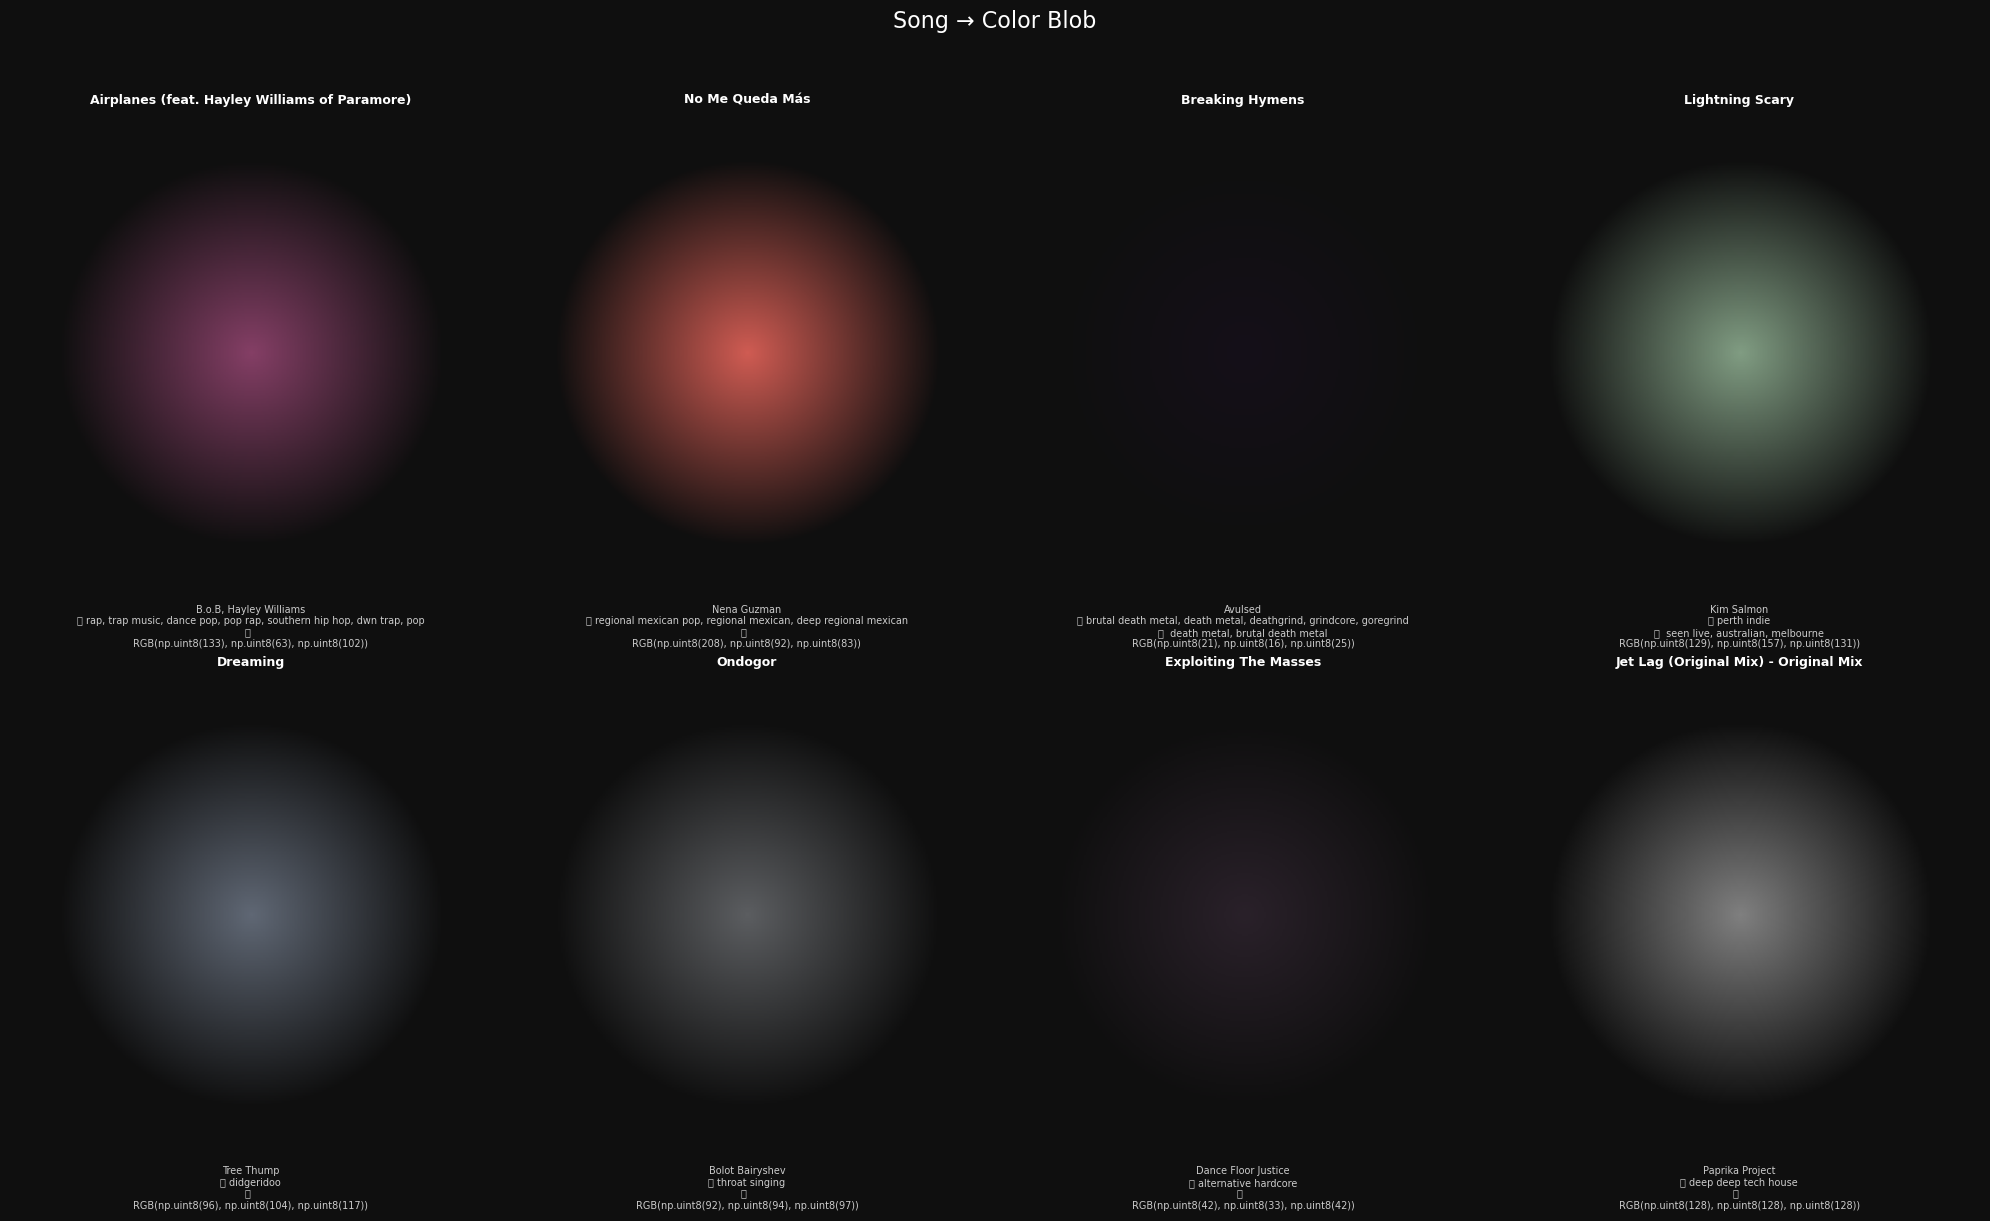

In [1]:
import json
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import math

DATA_DIR = "./data"

# ── Load latent embeddings ─────────────────────────────────────────────────────
with open(f"{DATA_DIR}/embeddings/latent_embeddings.json") as f:
    raw = json.load(f)

with open(f"{DATA_DIR}/embeddings/song_token_embeddings.json") as f:
    all_tokens = json.load(f)

genres    = list(raw.keys())
token2idx = {g: i for i, g in enumerate(genres)}
Z         = np.array(list(raw.values()), dtype=np.float32)
Z_norm    = Z / (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-9)

# ── Anchor colors ──────────────────────────────────────────────────────────────
ANCHORS = {
    "g_death metal":    np.array([20,  10,  30],  dtype=np.float32),
    "g_black metal":    np.array([10,  10,  10],  dtype=np.float32),
    "g_pop":            np.array([255, 105, 180],  dtype=np.float32),
    "g_jazz":           np.array([180, 120, 40],   dtype=np.float32),
    "g_classical":      np.array([200, 200, 255],  dtype=np.float32),
    "g_edm":            np.array([0,   255, 200],  dtype=np.float32),
    "g_tropical house": np.array([255, 200, 50],   dtype=np.float32),
    "g_blues":          np.array([30,  80,  180],  dtype=np.float32),
    "g_folk":           np.array([120, 180, 80],   dtype=np.float32),
    "g_reggaeton":      np.array([255, 80,  50],   dtype=np.float32),
    "g_house":          np.array([100, 0,   255],  dtype=np.float32),
    "g_rap":            np.array([50,  50,  50],   dtype=np.float32),
    "g_country":        np.array([210, 140, 50],   dtype=np.float32),
    "g_r&b":            np.array([150, 0,   100],  dtype=np.float32),
    "g_soul":           np.array([200, 80,  20],   dtype=np.float32),
}

anchor_keys   = [k for k in ANCHORS if k in token2idx]
anchor_idx    = np.array([token2idx[k] for k in anchor_keys])
anchor_vecs   = Z_norm[anchor_idx]
anchor_colors = np.array([ANCHORS[k] for k in anchor_keys])

# ── Token → RGB ────────────────────────────────────────────────────────────────
def token_to_rgb(token):
    if token not in token2idx:
        return None
    q       = Z_norm[token2idx[token]]
    sims    = anchor_vecs @ q
    sims    = sims - sims.max()
    weights = np.exp(sims * 5)
    weights /= weights.sum()
    return np.clip((weights[:, None] * anchor_colors).sum(0), 0, 255).astype(np.float32)

# ── Song → RGB (genres weighted most, tags least) ─────────────────────────────
FIELD_WEIGHTS = {"genres": 1.0, "subgenres": 0.6, "tags": 0.3}

def song_to_rgb(song):
    total_rgb, total_w = np.zeros(3, dtype=np.float32), 0.0
    for field, w in FIELD_WEIGHTS.items():
        for token in song.get(field, []):
            # try g_ prefix for genres/subgenres, t_ for tags
            prefix  = "t_" if field == "tags" else "g_"
            rgb     = token_to_rgb(f"{prefix}{token.lower()}")
            if rgb is not None:
                total_rgb += w * rgb
                total_w   += w
    if total_w == 0:
        return np.array([128, 128, 128], dtype=np.uint8)
    return np.clip(total_rgb / total_w, 0, 255).astype(np.uint8)

# ── Generate blob ──────────────────────────────────────────────────────────────
def generate_blob(song, size=300):
    rgb     = song_to_rgb(song)
    r, g, b = int(rgb[0]), int(rgb[1]), int(rgb[2])

    cx, cy  = size // 2, size // 2
    radius  = size // 2.5

    y_grid, x_grid = np.mgrid[0:size, 0:size]
    dist    = np.sqrt((x_grid - cx)**2 + (y_grid - cy)**2)
    t       = np.clip(dist / radius, 0, 1)
    falloff = 1 - t

    bg = np.array([15, 15, 15])
    fg = np.array([r, g, b])

    pixel_r = (fg[0] * falloff + bg[0] * (1 - falloff)).astype(np.uint8)
    pixel_g = (fg[1] * falloff + bg[1] * (1 - falloff)).astype(np.uint8)
    pixel_b = (fg[2] * falloff + bg[2] * (1 - falloff)).astype(np.uint8)

    img = Image.fromarray(np.stack([pixel_r, pixel_g, pixel_b], axis=2), mode='RGB')
    return img, rgb

# ── Load songs + tags for spotify lookup ──────────────────────────────────────
def read_csv(path):
    with open(path, encoding="utf-8") as f:
        lines = f.read().strip().splitlines()
    headers = [h.strip('"') for h in lines[0].split(',')]
    rows = []
    for line in lines[1:]:
        parts = [p.strip('"') for p in line.split(';')]
        if len(parts) == len(headers):
            rows.append(dict(zip(headers, parts)))
    return rows

songs = read_csv(f"{DATA_DIR}/csv/songs.csv")
tags  = read_csv(f"{DATA_DIR}/csv/tags.csv")

song_lookup  = {row["spotify_id"]: row for row in songs}

from collections import defaultdict
song_genres = defaultdict(set)
for row in songs:
    song_genres[row["spotify_id"]].add(row["genre_name"].lower())

song_tags = defaultdict(list)
for row in tags:
    song_tags[row["song_spotify_id"]].append(
        (row["tag"].lower(), int(row["popularity"]))
    )
for sid in song_tags:
    song_tags[sid] = [
        t for t, p in sorted(song_tags[sid], key=lambda x: -x[1])[:5]
    ]

# ── Spotify ID → blob ──────────────────────────────────────────────────────────
def blob_from_spotify_id(spotify_id, size=300):
    if spotify_id not in song_genres:
        print(f"'{spotify_id}' not found"); return None, None
    song = {
        "genres": list(song_genres[spotify_id]),
        "subgenres": [],
        "tags":   song_tags.get(spotify_id, [])
    }
    return generate_blob(song, size=size)

# ── Plot ───────────────────────────────────────────────────────────────────────
TEST_IDS = [
    "6lV2MSQmRIkycDScNtrBXO",
    "3CorimZuPQslcTZop2wp2Z",
    "4tNmBj1etOHrCN7otGjweK",
    "2fRAzmKCcnS9c1sAZd5uUM",
    "4zlj8rTf9XiKqZ1nAwF9Bj",
    "3Izog7LLV9zViAsBZaOJ5t",
    "3JJA96pbxukWALeKoBIL4i",
    "6VNE73gx82omH0XWSiq3FW",
]

n_cols = 4
n_rows = math.ceil(len(TEST_IDS) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 6 * n_rows))
fig.patch.set_facecolor('#0f0f0f')
axes = axes.flatten()

for i, sid in enumerate(TEST_IDS):
    img, rgb = blob_from_spotify_id(sid)
    row      = song_lookup.get(sid, {})

    genres_str = ", ".join(song_genres.get(sid, []))
    tags_str   = ", ".join(song_tags.get(sid, [])[:3])

    if img:
        axes[i].imshow(img)
        axes[i].set_facecolor('#0f0f0f')
        axes[i].set_title(
            row.get("name", sid),
            fontsize=9, fontweight='bold', color='white', pad=6
        )
        axes[i].set_xlabel(
            f"{row.get('artist', '')}\n🎵 {genres_str}\n🏷  {tags_str}\nRGB{tuple(rgb)}",
            fontsize=7, color='#cccccc', labelpad=8
        )
        axes[i].set_xticks([])
        axes[i].set_yticks([])
        for spine in axes[i].spines.values():
            spine.set_visible(False)

for j in range(len(TEST_IDS), len(axes)):
    axes[j].axis('off')

plt.suptitle("Song → Color Blob", fontsize=16, color='white', y=1.01)
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/song_blobs.png", dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

c:\Users\chand\miniconda3\envs\my_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\chand\miniconda3\envs\my_env\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


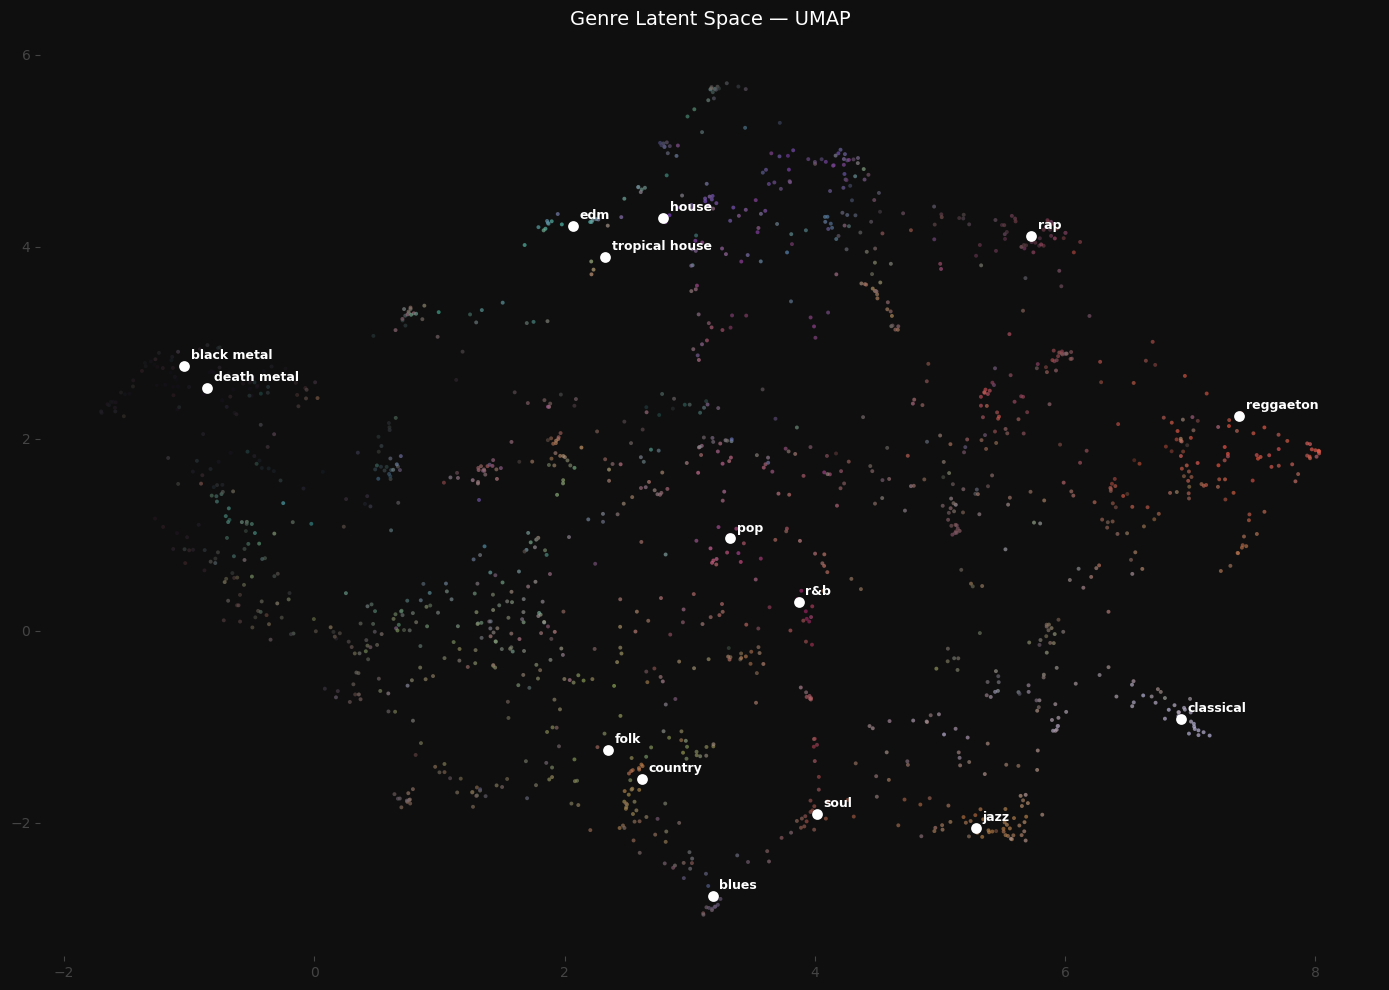

In [2]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# pip install umap-learn if you don't have it

# ── UMAP on latent vectors ─────────────────────────────────────────────────────
reducer   = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
Z_2d      = reducer.fit_transform(Z)

# ── Color each point by its genre color ───────────────────────────────────────
colors = []
for genre in genres:
    rgb = token_to_rgb(genre)
    if rgb is not None:
        colors.append(rgb / 255.0)  # matplotlib wants 0-1
    else:
        colors.append([0.5, 0.5, 0.5])

colors = np.array(colors)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

ax.scatter(
    Z_2d[:, 0], Z_2d[:, 1],
    c=colors,
    s=8,
    alpha=0.7,
    linewidths=0
)

# ── Label just the anchor genres so plot isn't overcrowded ────────────────────
for anchor in ANCHORS.keys():
    if anchor not in token2idx:
        continue
    idx = token2idx[anchor]
    x, y = Z_2d[idx]
    ax.annotate(
        anchor.replace("g_", ""),
        (x, y),
        color='white',
        fontsize=9,
        fontweight='bold',
        xytext=(5, 5),
        textcoords='offset points'
    )
    # white dot on anchor points so they stand out
    ax.scatter(x, y, s=60, c='white', zorder=5, linewidths=0)

ax.set_title("Genre Latent Space — UMAP", color='white', fontsize=14, pad=12)
ax.tick_params(colors='#444444')
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/umap_plot.png", dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()